# Week 3 Assignment - Customer Intelligence System using K-Means and DBSCAN Clustering

Business Problem - HELP International is a humanitarian NGO that aims to identify countries requiring immediate financial assistance based on socio-economic and health indicators. Since resources are limited, the organization needs a data-driven approach to prioritize countries that require aid the most.

Objective - The objective of this project is to build a Customer Intelligence (Country Segmentation) System using **Unsupervised Machine Learning** techniques.

The workflow includes:

- Data Loading and Cleaning
- Feature Scaling using StandardScaler
- K-Means Clustering
- Elbow Method for Optimal Cluster Selection
- Silhouette Score Evaluation
- DBSCAN Clustering
- PCA Visualization
- Cluster Analysis and Business Recommendations

The final outcome is to identify groups of countries with similar development characteristics and provide meaningful insights that can assist HELP International in making informed funding decisions.

In [24]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

# Plot Style
plt.style.use("ggplot")

In [25]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Country-data.csv")

print("Dataset Loaded Successfully!")
print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
display(df.head())

Dataset Loaded Successfully!

Number of Rows    : 167
Number of Columns : 10


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Dataset Inspection - Before performing preprocessing and clustering, it is important to understand the dataset's structure and quality.

In this section, we will:
- Inspect the dataset structure
- Check data types
- Generate descriptive statistics
- Identify missing values
- Detect duplicate records

This helps ensure the dataset is suitable for clustering analysis.

In [26]:
# Dataset Information

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(display(df.dtypes.to_frame(name="Data Type")))

print("\nDataset Info:")
df.info()

Dataset Information

Shape of Dataset:
(167, 10)

Column Names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data Types:


,Data Type
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


None


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [27]:
# Descriptive Statistics

print("=" * 60)
print("Statistical Summary")
print("=" * 60)

display(display(df.describe().T.round(2)))

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


None

In [28]:
# Data Cleaning & Preprocessing

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("=" * 60)
print("Missing Values")
print("=" * 60)
display(df.isnull().sum().to_frame(name="Missing Values"))

# Check duplicate rows
print("\nDuplicate Records:", df.duplicated().sum())

# Remove duplicate rows (if any)
df = df.drop_duplicates()

# Convert feature columns to numeric (excluding country column)
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values with median (only if any exist)
if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)

print("\nData preprocessing completed successfully.")

Missing Values


,Missing Values
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Records: 0

Data preprocessing completed successfully.


# Feature Selection and Scaling

Machine learning algorithms such as **K-Means** and **DBSCAN** are distance-based algorithms. Since the features in this dataset have different scales (for example, income ranges from hundreds to over one lakh, while health ranges only between 1 and 18), feature scaling is essential.

In this section, we:

- Separate the country names from numerical features.
- Standardize all numerical features using **StandardScaler**.
- Create a scaled feature matrix for clustering.

In [29]:
# Separate Country Names and Numerical Features
country_names = df["country"]
features = df.drop(columns=["country"])
print("Country names separated successfully.")
print("\nShape of Feature Matrix:", features.shape)
display(features.head())

Country names separated successfully.

Shape of Feature Matrix: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [30]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

print("Feature Scaling Completed Successfully!")
display(scaled_df.head())

Feature Scaling Completed Successfully!


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


In [31]:
# Verify Scaling
print("Mean of Scaled Features (approx. 0):")
display(scaled_df.mean().round(2))

print("\nStandard Deviation of Scaled Features (approx. 1):")
display(scaled_df.std().round(2))

Mean of Scaled Features (approx. 0):


,0
child_mort,-0.0
exports,0.0
health,0.0
imports,0.0
income,-0.0
inflation,-0.0
life_expec,0.0
total_fer,0.0
gdpp,0.0



Standard Deviation of Scaled Features (approx. 1):


,0
child_mort,1.0
exports,1.0
health,1.0
imports,1.0
income,1.0
inflation,1.0
life_expec,1.0
total_fer,1.0
gdpp,1.0


# Finding the Optimal Number of Clusters (Elbow Method)

The Elbow Method helps determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS), also called inertia, against different values of **K**. The point where the curve starts to flatten (the "elbow") indicates the optimal number of clusters.

In [32]:
# Elbow Method

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

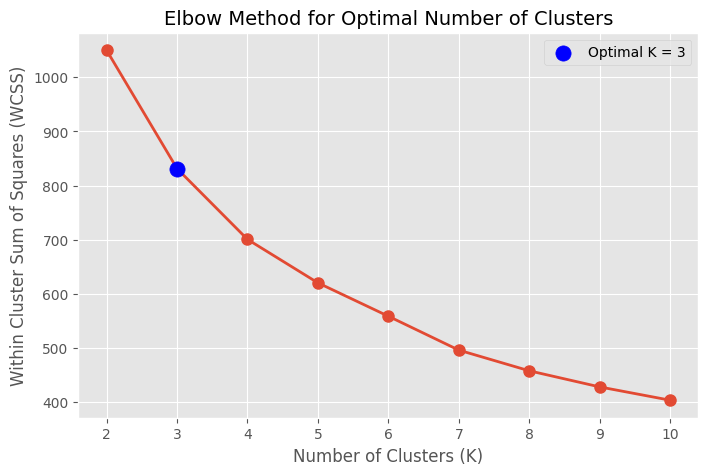

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.scatter(
    3,
    inertia[1],   # since k_values starts at 2
    color='blue',
    s=120,
    zorder=5,
    label='Optimal K = 3'
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Sum of Squares (WCSS)")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

Interpretation - The Elbow Method indicates that **K = 3** is an appropriate choice for clustering. At this point, the reduction in inertia begins to slow, suggesting that adding more clusters provides only marginal improvement. Therefore, **K = 3** is selected for the K-Means clustering model.

In [34]:
print("Based on the Elbow Method, the optimal number of clusters is selected as K = 3.")

Based on the Elbow Method, the optimal number of clusters is selected as K = 3.


# K-Means Clustering

Based on the Elbow Method, **K = 3** is selected as the optimal number of clusters. The K-Means algorithm partitions countries into three distinct groups based on their socio-economic and health indicators. These clusters will later be analyzed to identify countries requiring the highest priority for international aid.

In [35]:
# Train K-Means Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_df)
print("K-Means Model Trained Successfully!")

K-Means Model Trained Successfully!


In [36]:
# Add Cluster Labels
df["Cluster"] = cluster_labels
print("Cluster labels added to dataset.")
display(df.head())

Cluster labels added to dataset.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [37]:
# Cluster Distribution
cluster_counts = df["Cluster"].value_counts().sort_index()
print("Number of Countries in Each Cluster:\n")
display(cluster_counts.to_frame(name="Number of Countries"))

Number of Countries in Each Cluster:



,Number of Countries
Cluster,
0,36
1,47
2,84


In [38]:
# Silhouette Score
sil_score = silhouette_score(
    scaled_df,
    cluster_labels
)

print(f"Silhouette Score : {sil_score:.3f}")

Silhouette Score : 0.283


Interpretation - The Silhouette Score measures how well each country fits within its assigned cluster compared to other clusters.

- A score close to 1 indicates well-separated clusters.
- A score close to 0 indicates overlapping clusters.
- Negative values suggest poor clustering.

A positive silhouette score indicates that the selected clustering configuration provides meaningful separation among the countries.

# Cluster-wise Statistical Summary
To understand the characteristics of each cluster, we calculate the average value of every socio-economic and health indicator for each cluster. This helps identify which clusters represent developed, developing, or underdeveloped countries.

In [39]:
# Cluster Summary
cluster_summary = (
    df
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)
cluster_summary.index.name = "Cluster ID"
display(cluster_summary)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster ID,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


Interpretation - The cluster summary provides the average socio-economic and health indicators for each cluster.

- **Cluster 0** represents economically developed countries with high income, high GDP per capita and long life expectancy.
- **Cluster 1** represents the least developed countries, characterized by high child mortality, low income and lower life expectancy.
- **Cluster 2** represents developing countries with moderate socio-economic indicators.

These findings will be used later to recommend countries that should receive priority support from HELP International.

In [40]:
print("Average values for each cluster are shown above.")
print("These statistics will be used later for business interpretation and recommendations.")

Average values for each cluster are shown above.
These statistics will be used later for business interpretation and recommendations.


# PCA Visualization of Clusters

Since the dataset contains multiple numerical features, it is difficult to visualize the clusters directly.

**Principal Component Analysis (PCA)** reduces the data into two principal components while preserving most of the important information. This enables us to visualize how well the countries are separated into clusters.

In [41]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(
    pca_components,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = cluster_labels
display(pca_df.head())

,Principal Component 1,Principal Component 2,Cluster
0,-2.91,0.10,1
1,0.43,-0.59,2
2,-0.29,-0.46,2
3,-2.93,1.70,1
4,1.03,0.14,2


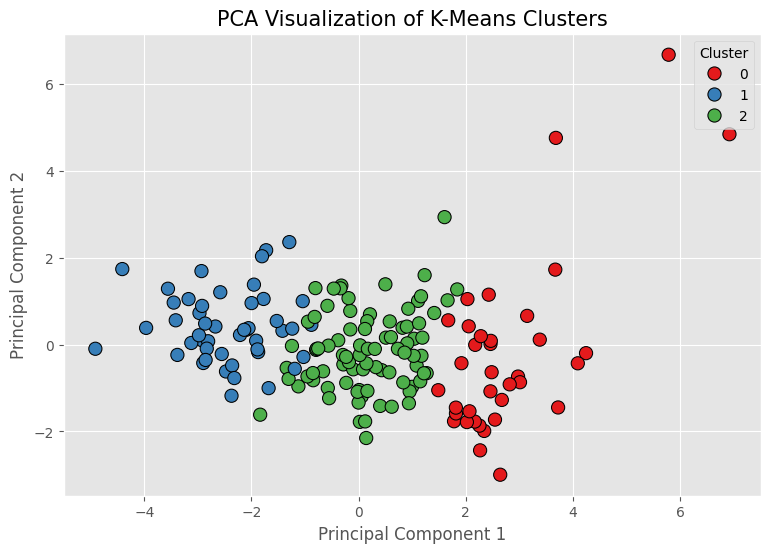

In [42]:
# PCA Scatter Plot
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Cluster",
    palette="Set1",
    s=90,
    edgecolor="black"
)

plt.title("PCA Visualization of K-Means Clusters", fontsize=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

Interpretation - The PCA plot projects the multidimensional country data into two principal components while preserving the overall cluster structure. The visualization shows that the countries are grouped into distinct segments, indicating that the K-Means algorithm has successfully identified meaningful patterns within the dataset.

# DBSCAN Clustering

Unlike K-Means, **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** groups countries based on data density instead of requiring a predefined number of clusters. It can also identify potential outliers (noise points), making it useful for comparison with K-Means clustering.

In [43]:
# Train DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(scaled_df)
print("DBSCAN Model Trained Successfully!")

DBSCAN Model Trained Successfully!


In [44]:
# DBSCAN Cluster Distribution
dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()
dbscan_counts.index.name = "DBSCAN Cluster"
display(dbscan_counts.to_frame(name="Number of Countries"))

,Number of Countries
DBSCAN Cluster,
-1,30
0,137


In [45]:
# Add DBSCAN Labels
df["DBSCAN_Cluster"] = dbscan_labels
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0


Interpretation - DBSCAN groups countries based on density and may classify certain observations as **noise** (represented by **-1**). Comparing DBSCAN with K-Means helps evaluate different clustering strategies for identifying meaningful country segments.
DBSCAN identified one dense cluster and several noise points (labelled **-1**).
Unlike K-Means, DBSCAN does not require a predefined number of clusters and is effective at detecting countries with unusual socio-economic characteristics. These outlier countries may require individual analysis rather than being grouped with the majority.

Cluster Analysis and Business Insights - The cluster statistics help identify the socio-economic characteristics of each country group.
These observations provide meaningful insights for HELP International to prioritize countries requiring financial assistance.

In [46]:
# Display Countries in Each Cluster
for cluster in sorted(df["Cluster"].unique()):

    print("=" * 60)
    print(f"Cluster {cluster}")
    print("=" * 60)

    countries = df[df["Cluster"] == cluster]["country"].tolist()

    print(countries)
    print()

Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Tog

## Observations ~

Observation 1 - Cluster **0** represents the most economically developed countries. These countries have the **highest average income (45,672)**, **highest GDP per capita (42,494)**, **lowest child mortality (5.00)** and **highest life expectancy (80.13 years)**. These countries require comparatively lower financial assistance.

Observation 2 - Cluster **1** represents the least developed countries. It has the **highest child mortality (92.96)**, **lowest average income (3,942)**, **lowest GDP per capita (1,922)** and **lowest life expectancy (59.19 years)**. This cluster should be considered the **highest priority** for financial aid.

Observation 3 - Cluster **2** represents developing countries with moderate socio-economic conditions. The countries in this cluster have moderate income, GDP and life expectancy, indicating steady development but still requiring continued support.

Observation 4 - The PCA visualization demonstrates that the K-Means algorithm successfully separates countries into distinct socio-economic groups, confirming meaningful segmentation of the dataset.

Observation 5 - DBSCAN identified **30 countries as potential noise/outliers**, indicating that some countries exhibit unique socio-economic characteristics that differ significantly from the majority of the dataset.

Business Recommendation - Based on the clustering results, **Cluster 1** represents countries with the highest child mortality, lowest income, lowest GDP per capita and lowest life expectancy. These countries should receive the highest funding priority from HELP International.
Cluster 2 represents developing countries that may benefit from continued economic and healthcare support.
Cluster 0 consists of developed countries with strong socio-economic indicators and therefore requires comparatively lower priority for humanitarian aid.

# Conclusion

This project successfully developed a **Customer Intelligence System** for country segmentation using **K-Means** and **DBSCAN** clustering techniques. The Elbow Method identified **K = 3** as the optimal number of clusters, while the positive Silhouette Score confirmed satisfactory cluster quality. PCA visualization demonstrated clear separation between the identified clusters, and DBSCAN highlighted potential outlier countries.

From the cluster analysis:

- **Cluster 0** represents developed countries with high income, high GDP and low child mortality.
- **Cluster 1** contains underdeveloped countries with low income, high child mortality and low life expectancy, making them the highest priority for international aid.
- **Cluster 2** consists of developing countries with moderate socio-economic indicators.

These findings provide actionable insights that can help **HELP International** prioritize resource allocation and make informed humanitarian funding decisions.